In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from sklearn.decomposition import NMF



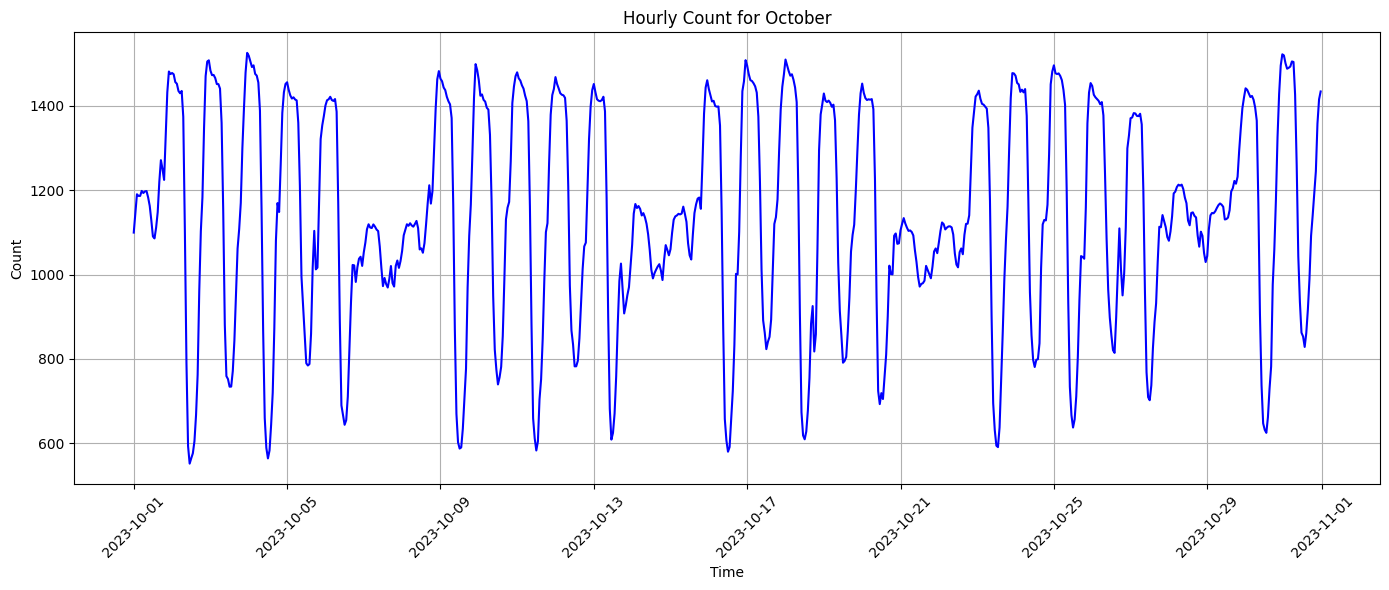

In [2]:
# Load necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Read the CSV file
data = pd.read_csv("WVE.csv")

# Step 2: Convert 'datetime' column to datetime format
data['datetime'] = pd.to_datetime(data['datetime'], format='%Y-%m-%d %H:%M:%S')

# Step 3: Sample data hourly using pandas
data['hour'] = data['datetime'].dt.floor('H')  # Group data by hour
hourly_data = data.groupby('hour')['count'].mean().reset_index()  # Compute average count per hour

# Step 4: Filter for the month of October
october_data = hourly_data[hourly_data['hour'].dt.month == 10]  # Extract data only for October

# Step 5: Plot the count vs. time graph using matplotlib and seaborn
plt.figure(figsize=(14, 6))
sns.lineplot(data=october_data, x='hour', y='count', color='blue')

plt.title('Hourly Count for October')
plt.xlabel('Time')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(visible=True)
plt.tight_layout()
plt.show()


In [3]:

time_series = october_data['count'].values

In [4]:


# def logistic_map(r, x0, n):
#     """Generates a time series of the logistic map."""
#     x = np.zeros(n)
#     x[0] = x0
#     for i in range(1, n):
#         x[i] = r * x[i-1] * (1 - x[i-1])
#     return x

# # Set parameters
# r = 4
#   # Growth rate
# x0 = 0.4  # Initial population
# n = 10000  # Number of iterations

# # Generate time series
# time_series = logistic_map(r, x0, n)

# # Plot
# plt.plot(time_series, marker='o', linestyle='-')

# plt.xlabel("Time")
# plt.xlim(0, 250)
# plt.ylabel("Population")
# plt.title("Logistic Map Time Series (r = {})".format(r))
# plt.show()

In [5]:
(time_series == 0).any()

False

In [6]:
min_index = np.argmin(time_series)
min_value = time_series[min_index]
min_index, min_value

(35, 551.875)

In [7]:
time_series[60:90]

array([ 734.22222222,  734.44444444,  771.33333333,  843.41666667,
        956.29166667, 1061.73809524, 1107.76190476, 1169.79166667,
       1299.375     , 1394.40277778, 1478.55555556, 1525.33333333,
       1518.5       , 1504.66666667, 1491.79166667, 1495.75      ,
       1475.54166667, 1471.39583333, 1455.        , 1388.45833333,
       1156.48611111,  867.38888889,  659.875     ,  589.125     ,
        564.20833333,  583.20833333,  644.04166667,  720.08333333,
        873.08333333, 1080.08333333])

In [8]:
time_series.shape

(744,)

In [9]:
time_series_matrix = time_series[:].reshape(24, 31)
print(time_series_matrix.shape)

(24, 31)


### SVD on the time series data (when reshaped into 100x100 matrix)

In [10]:
U, S, Vt = svd(time_series_matrix, full_matrices=False)
print("U matrix:\n", U)
print("Singular values:\n", S)
print("Vt matrix:\n", Vt)

U matrix:
 [[ 2.27321360e-01  2.08736825e-03 -1.44293779e-01 -3.34459405e-01
  -1.22045802e-01  6.50885019e-02 -8.79546651e-02 -9.53745045e-02
   1.04309722e-01  3.09286026e-01 -2.21907484e-01 -1.31047136e-01
  -2.62882219e-01 -3.08998147e-01  7.50243763e-02  9.64728089e-02
  -4.97566082e-01 -6.41137199e-02 -2.86977355e-01  1.54977312e-01
   1.95816932e-01  5.72330867e-02  1.48244003e-01 -7.44506215e-02]
 [ 1.91923570e-01  4.22265937e-01 -8.19461988e-02 -1.66601958e-02
   2.33116396e-01  2.90826716e-01  1.38844741e-01  2.61761150e-01
   1.61054318e-03 -1.73360154e-01 -7.35991836e-03  4.80176186e-02
   1.88402085e-01 -4.48232019e-02  3.18316365e-01 -2.69934784e-02
  -1.39376837e-01  5.09566964e-02 -5.77892736e-02 -1.17494170e-01
   1.89236490e-01 -5.44582479e-01 -8.72918468e-02  1.38115983e-03]
 [ 2.01396269e-01 -4.03269439e-02  4.04855024e-01 -7.48205544e-02
   1.71616474e-01 -3.13675530e-01 -2.19490133e-01  9.40537239e-02
  -3.29420158e-01  1.86714941e-01  9.37265573e-02 -7.74423409e-

In [11]:
U.shape, S.shape, Vt.shape

((24, 24), (24,), (24, 31))

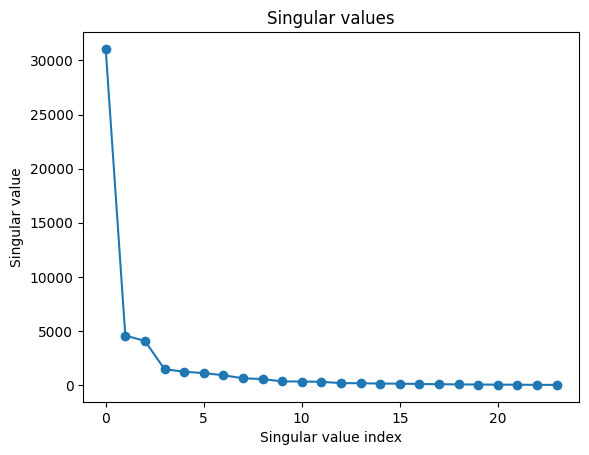

In [12]:
plt.plot(S, marker='o', linestyle='-')
plt.xlabel("Singular value index")
plt.ylabel("Singular value")
plt.title("Singular values")
plt.show()


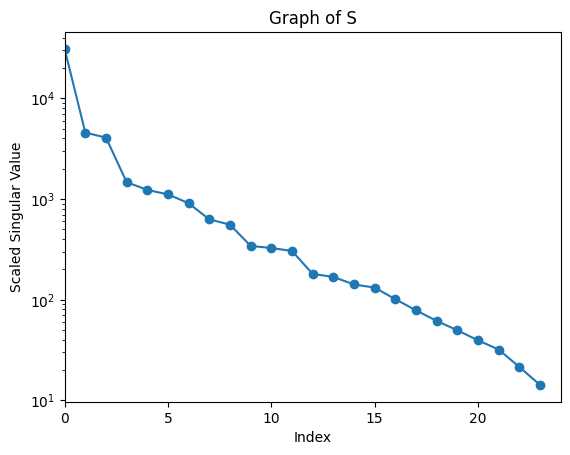

In [13]:
plt.plot(S, marker='o', linestyle='-')
plt.yscale('log')
plt.xlim(0, 24)
plt.xlabel('Index')
plt.ylabel('Scaled Singular Value')
plt.title('Graph of S')
plt.show()

In [14]:

def rank_approximation(U, S, Vt, rank):
  return U[:, :rank] @ np.diag(S[:rank]) @ Vt[:rank, :] #low rank approximation

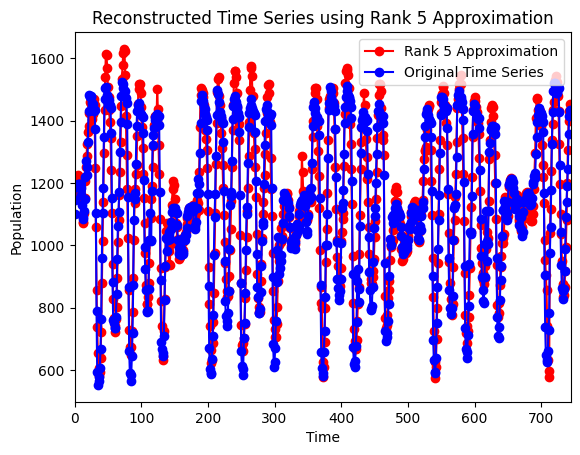

In [15]:
rank_5_approximation = rank_approximation(U, S, Vt, 5)

# Flatten the matrix to get the time series
reconstructed_time_series_rank_5 = rank_5_approximation.flatten()

# Plot the reconstructed time series
plt.plot(reconstructed_time_series_rank_5, marker='o', linestyle='-', color='red', label='Rank 5 Approximation')
plt.plot(time_series, marker='o', linestyle='-', color='blue', label='Original Time Series')
plt.xlabel("Time")
plt.xlim(0, 744)
plt.ylabel("Population")
plt.title("Reconstructed Time Series using Rank 5 Approximation")
plt.legend()
plt.show()

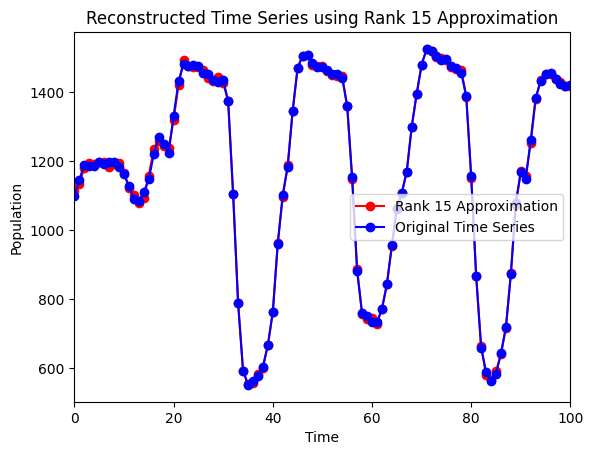

In [16]:
rank_20_approximation = rank_approximation(U, S, Vt, 15)

# Flatten the matrix to get the time series
reconstructed_time_series_rank_20 = rank_20_approximation.flatten()
# Plot the reconstructed time series
plt.plot(reconstructed_time_series_rank_20, marker='o', linestyle='-', color='red', label='Rank 15 Approximation')
plt.plot(time_series, marker='o', linestyle='-', color='blue', label='Original Time Series')
plt.xlabel("Time")
plt.xlim(0, 100)
plt.ylabel("Population")
plt.title("Reconstructed Time Series using Rank 15 Approximation")
plt.legend()
plt.show()

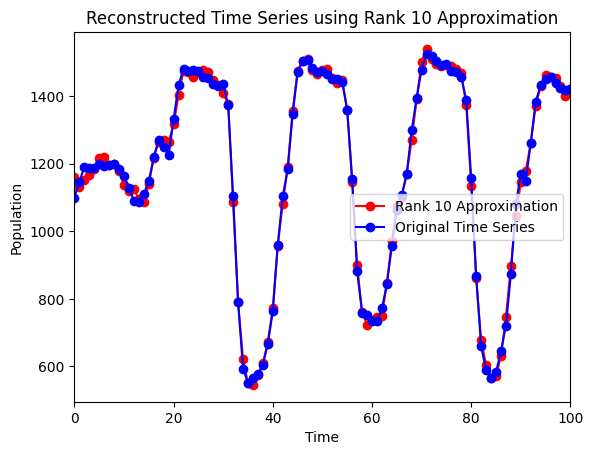

In [17]:
rank_60_approximation = rank_approximation(U, S, Vt, 10)

# Flatten the matrix to get the time series
reconstructed_time_series_rank_60 = rank_60_approximation.flatten()
# Plot the reconstructed time series
plt.plot(reconstructed_time_series_rank_60, marker='o', linestyle='-', color='red', label='Rank 10 Approximation')
plt.plot(time_series, marker='o', linestyle='-', color='blue', label='Original Time Series')
plt.xlabel("Time")
plt.xlim(0, 100)
plt.ylabel("Population")
plt.title("Reconstructed Time Series using Rank 10 Approximation")
plt.legend()
plt.show()

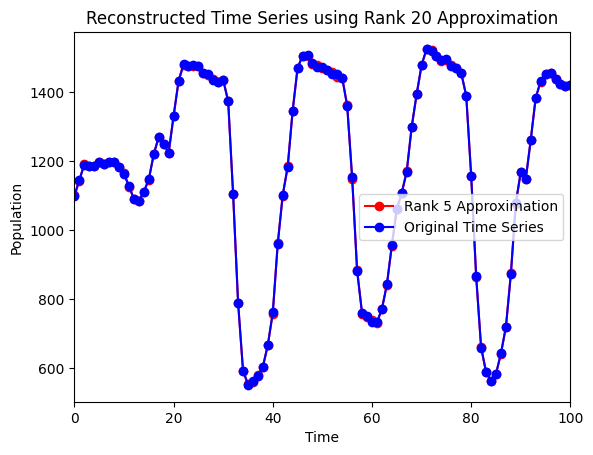

In [18]:
rank_90_approximation = rank_approximation(U, S, Vt, 20)

# Flatten the matrix to get the time series
reconstructed_time_series_rank_90 = rank_90_approximation.flatten()
# Plot the reconstructed time series
plt.plot(reconstructed_time_series_rank_90, marker='o', linestyle='-', color='red', label='Rank 5 Approximation')
plt.plot(time_series, marker='o', linestyle='-', color='blue', label='Original Time Series')
plt.xlabel("Time")
plt.xlim(0, 100)
plt.ylabel("Population")
plt.title("Reconstructed Time Series using Rank 20 Approximation")
plt.legend()
plt.show()

### SVD on the time series data (when reshaped into using hankel matrix)

In [19]:
def SSA_decomposition(time_series, window_length):
    """Perform Singular Spectrum Analysis (SSA) on the time series."""
    N = len(time_series)
    K = N - window_length + 1
    print(K)
    X = np.array([time_series[i:i+window_length] for i in range(K)]).T # Create the trajectory matrix

    U, S, Vt = svd(X, full_matrices=False) # Perform SVD

    return U, S, Vt, X


window_length = 372# Initializing window length

U_ssa, S_ssa, Vt_ssa, X_ssa = SSA_decomposition(time_series, window_length)
X_ssa.shape

373


(372, 373)

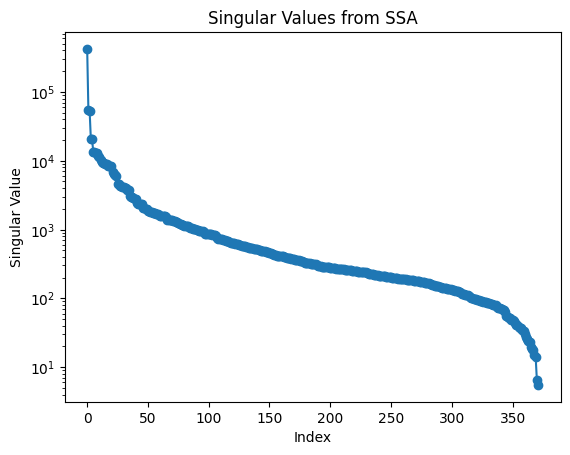

In [20]:
# Plot singular values
plt.plot(S_ssa, marker='o', linestyle='-')
plt.xlabel('Index')
plt.yscale('log')
plt.ylabel('Singular Value')
plt.title('Singular Values from SSA')
plt.show()

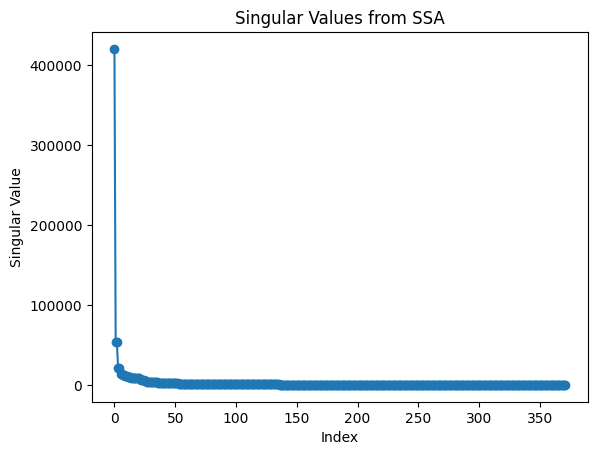

In [21]:
# Plot singular values
plt.plot(S_ssa, marker='o', linestyle='-')
plt.xlabel('Index')
# plt.xlim(0, 2000)
# plt.ylim(0, 100)
plt.ylabel('Singular Value')
plt.title('Singular Values from SSA')
plt.show()

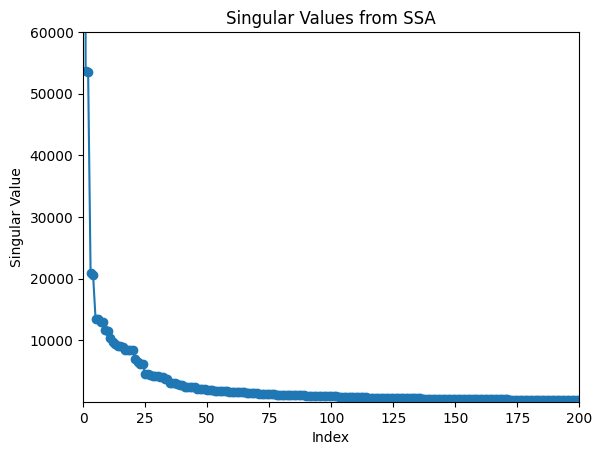

In [22]:
# Plot singular values
plt.plot(S_ssa, marker='o', linestyle='-')
plt.xlabel('Index')
plt.xlim(0, 200)
plt.ylim(1, 60000)
plt.ylabel('Singular Value')
plt.title('Singular Values from SSA')
plt.show()

In [23]:
S_ssa[-1]

5.517375677015754

In [24]:
# Reconstruct the time series using the first few components
def reconstruct_time_series(U, S, Vt, num_components):
    """Reconstruct the time series using the first few components."""
    return np.dot(U[:, :num_components], np.dot(np.diag(S[:num_components]), Vt[:num_components, :]))

# Number of components to use for reconstruction
num_components = 300
# Reconstruct the time series
reconstructed_time_series = reconstruct_time_series(U_ssa, S_ssa, Vt_ssa, num_components)

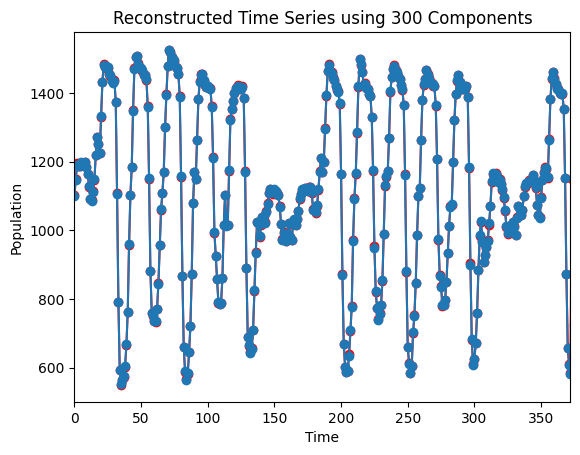

In [25]:

# Plot the reconstructed time series
plt.plot(reconstructed_time_series.flatten(), marker='o', linestyle='-', color='red')
plt.plot(time_series, marker='o', linestyle='-')
plt.xlabel("Time")
plt.xlim(0, 372)
plt.ylabel("Population")
plt.title(f"Reconstructed Time Series using {num_components} Components")
plt.show()

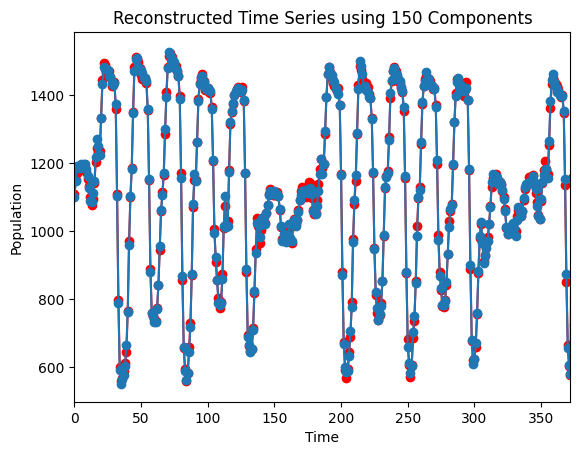

In [26]:
# Plot the reconstructed time series
plt.plot(reconstruct_time_series(U_ssa, S_ssa, Vt_ssa, 150).flatten(), marker='o', linestyle='-', color='red')
plt.plot(time_series, marker='o', linestyle='-')
plt.xlabel("Time")
plt.xlim(0, 372)
plt.ylabel("Population")
plt.title(f"Reconstructed Time Series using {150} Components")
plt.show()

In [27]:
import numpy as np
# Compute the error between the original and reconstructed time series
def calculate_error(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)  # Mean Squared Error
    mae = np.mean(np.abs(original - reconstructed))  # Mean Absolute Error
    return mse, mae

# Calculate the error
mse, mae = calculate_error(X_ssa, reconstruct_time_series(U_ssa, S_ssa, Vt_ssa, 150))

# Print the results
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")


Mean Squared Error: 81.83539587275224
Mean Absolute Error: 6.990350462669929


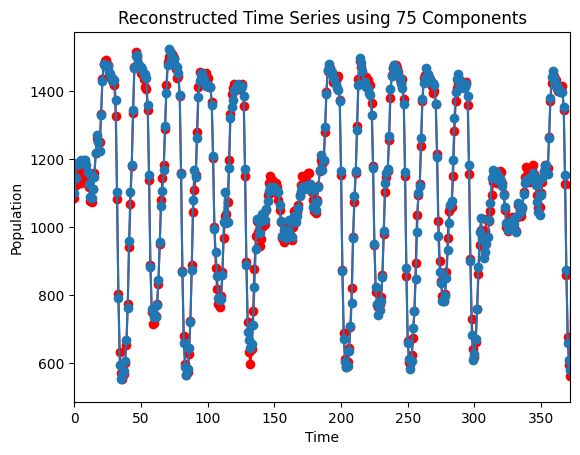

In [28]:
# Plot the reconstructed time series
plt.plot(reconstruct_time_series(U_ssa, S_ssa, Vt_ssa, 75).flatten(), marker='o', linestyle='-', color='red')
plt.plot(time_series, marker='o', linestyle='-')
plt.xlabel("Time")
plt.xlim(0, 372)
plt.ylabel("Population")
plt.title(f"Reconstructed Time Series using {75} Components")
plt.show()

In [29]:
# Calculate the error
mse, mae = calculate_error(X_ssa, reconstruct_time_series(U_ssa, S_ssa, Vt_ssa, 75))

# Print the results
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 423.904984463062
Mean Absolute Error: 15.535435511820632


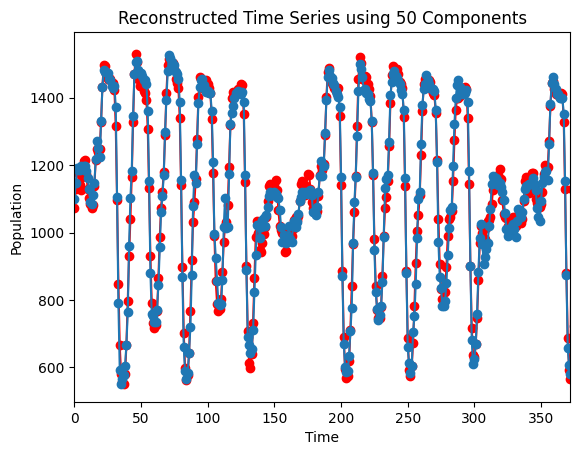

In [30]:
# Plot the reconstructed time series
plt.plot(reconstruct_time_series(U_ssa, S_ssa, Vt_ssa, 50).flatten(), marker='o', linestyle='-', color='red')
plt.plot(time_series, marker='o', linestyle='-')
plt.xlabel("Time")
plt.xlim(0, 372)
plt.ylabel("Population")
plt.title(f"Reconstructed Time Series using {50} Components")
plt.show()

In [31]:
# Calculate the error
mse, mae = calculate_error(X_ssa, reconstruct_time_series(U_ssa, S_ssa, Vt_ssa, 50))

# Print the results
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 865.560568883869
Mean Absolute Error: 22.550164249854326


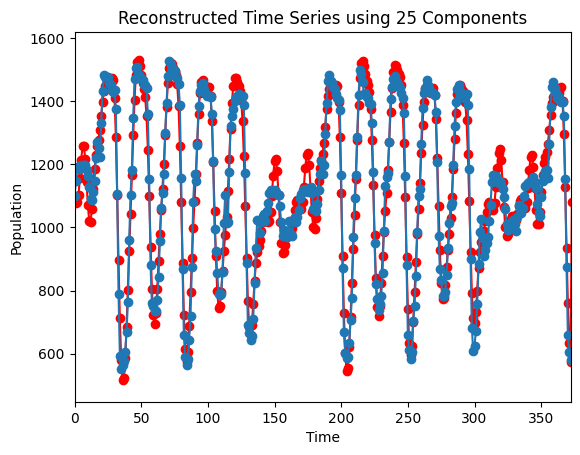

In [32]:
# Plot the reconstructed time series
plt.plot(reconstruct_time_series(U_ssa, S_ssa, Vt_ssa, 25).flatten(), marker='o', linestyle='-', color='red')
plt.plot(time_series, marker='o', linestyle='-')
plt.xlabel("Time")
plt.xlim(0, 372)
plt.ylabel("Population")
plt.title(f"Reconstructed Time Series using {25} Components")
plt.show()

In [33]:
# Calculate the error
mse, mae = calculate_error(X_ssa, reconstruct_time_series(U_ssa, S_ssa, Vt_ssa, 25))

# Print the results
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 2798.967333205986
Mean Absolute Error: 40.60290405992939


In [34]:
reconstruct_time_series(U_ssa, S_ssa, Vt_ssa, 24).flatten()[700:743]

array([1032.02307459, 1031.63142146, 1027.80130407, 1031.71974397,
       1049.40473375, 1075.90606502, 1094.25064898, 1095.18760908,
       1081.74748429, 1065.07080561, 1060.47961885, 1079.23340522,
       1121.91252502, 1174.85097088, 1214.30593558, 1220.45788764,
       1186.82590941, 1125.65528564, 1061.62144433, 1022.35831216,
       1021.8543553 , 1058.75352388, 1114.64810593, 1167.7585115 ,
       1201.458775  , 1217.76416532, 1230.46894029, 1253.72633627,
       1294.42607446, 1348.19885712, 1393.15156526, 1417.29052774,
       1422.32316971, 1418.47867226, 1419.67056648, 1431.22384811,
       1446.29963379, 1443.66824709, 1398.75639106, 1293.52646246,
       1129.15134498,  931.97441905,  748.60221226])

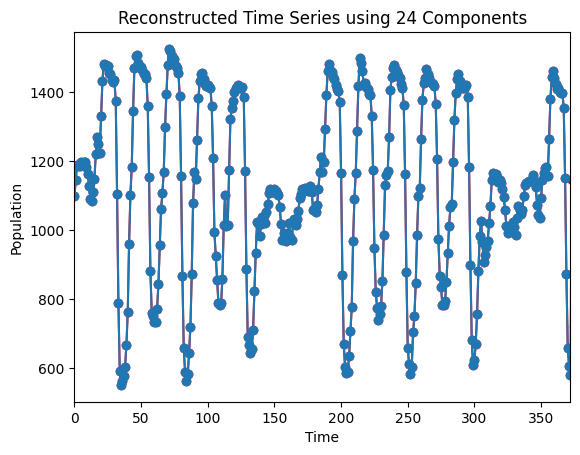

In [35]:
# Plot the reconstructed time series
plt.plot(reconstruct_time_series(U_ssa, S_ssa, Vt_ssa, 372).flatten(), marker='o', linestyle='-', color='red')
plt.plot(time_series, marker='o', linestyle='-')
plt.xlabel("Time")
plt.xlim(0, 372)
plt.ylabel("Population")
plt.title(f"Reconstructed Time Series using {24} Components")
plt.show()

In [36]:
# Check for negative values in H_20 matrix
negative_values_in_U = (U_ssa < 0).any()
print("Are there any negative values in H_20 matrix?", negative_values_in_U)

# Check for negative values in W_20 matrix
negative_values_in_W = (S_ssa < 0).any()
print("Are there any negative values in W_20 matrix?", negative_values_in_W)
# Check for negative values in W_20 matrix
negative_values_in_vt = (Vt_ssa < 0).any()
print("Are there any negative values in W_20 matrix?", negative_values_in_vt)

Are there any negative values in H_20 matrix? True
Are there any negative values in W_20 matrix? False
Are there any negative values in W_20 matrix? True


W matrix:
 [[1.06532834e+02 4.67163418e+01 2.52076950e+01 ... 0.00000000e+00
  3.98656370e-01 0.00000000e+00]
 [6.13212959e+01 3.43554084e+01 2.18886319e+01 ... 8.13158842e+00
  1.05041018e+00 0.00000000e+00]
 [5.69333837e+01 7.96591096e+01 0.00000000e+00 ... 0.00000000e+00
  3.86262497e+00 0.00000000e+00]
 ...
 [8.94516108e+01 4.77299719e+01 1.90673583e+01 ... 1.36697224e+00
  0.00000000e+00 1.65739224e+00]
 [5.57308171e+01 5.77761479e+01 3.94489668e+00 ... 6.70136060e+00
  1.94762190e-02 0.00000000e+00]
 [7.47446650e+01 5.34357528e+01 1.38356168e+00 ... 0.00000000e+00
  2.15393230e-01 1.90184418e+00]]
H matrix:
 [[ 4.70931367  2.31729183  1.67083673 ...  4.74247096  3.36985608
   1.68548736]
 [ 0.91268408  2.32560954  5.63806858 ...  0.86946271  2.9052241
   1.26088785]
 [ 5.65155449 10.59719794  7.19609968 ...  2.77471609  2.66859334
   0.60851766]
 ...
 [ 6.55658551  8.29316394  8.77073322 ...  1.79557708  2.31370367
   4.91947144]
 [ 0.05842267  5.85621691  1.38310248 ... 10.18377

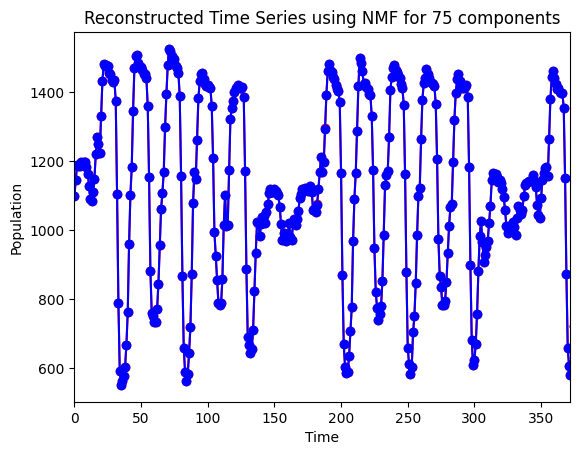

In [37]:

# Perform NMF
model = NMF(n_components=75, init='random', random_state=0)
W_20 = model.fit_transform(time_series_matrix)
H_20 = model.components_

print("W matrix:\n", W_20)
print("H matrix:\n", H_20)

# Plot the reconstructed time series
reconstructed_time_series_20 = W_20 @ H_20
plt.plot(reconstructed_time_series_20.flatten(), marker='o', linestyle='-', color='red')
plt.plot(time_series, marker='o', linestyle='-', color='Blue')
plt.xlabel("Time")
plt.xlim(0, 372)
plt.ylabel("Population")
plt.title("Reconstructed Time Series using NMF for 75 components")
plt.show()

In [38]:
time_series_matrix.shape

(24, 31)

In [39]:
reconstructed_time_series_20.flatten()[91]

1148.2875964746324

In [40]:
X_ssa.shape

(372, 373)

W matrix:
 [[ 64.84194039  25.18577389   5.55179658 ...   0.17147967   0.
    0.        ]
 [ 97.98027652  36.55684637  10.85437154 ...   0.           0.33138619
    3.56645953]
 [ 84.12152075  29.65123663   8.18997862 ...   0.66644051   1.21554787
    8.84788871]
 ...
 [137.28539706  44.13744139  19.73935632 ...   0.           0.
    0.        ]
 [133.82193532  48.03527955  19.17931971 ...   0.           0.
    0.87308909]
 [ 99.40887607  37.50097329  15.59576967 ...   0.           0.
    0.        ]]
H matrix:
 [[2.51954376 2.31979865 1.20550129 ... 2.4212195  1.42764725 1.20097293]
 [0.         0.01065233 1.36695894 ... 1.10825706 2.47963121 1.52567477]
 [2.44754821 3.28162994 5.08691686 ... 2.52402268 2.49527321 4.93790135]
 ...
 [0.         3.68146239 5.30141462 ... 3.6403828  5.1525646  1.52835809]
 [0.         0.         1.40558887 ... 1.90910082 6.25017518 5.73327759]
 [0.12780743 0.38381504 0.7730502  ... 2.01448257 1.82884762 0.        ]]


c:\Users\divya\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_nmf.py:1770: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


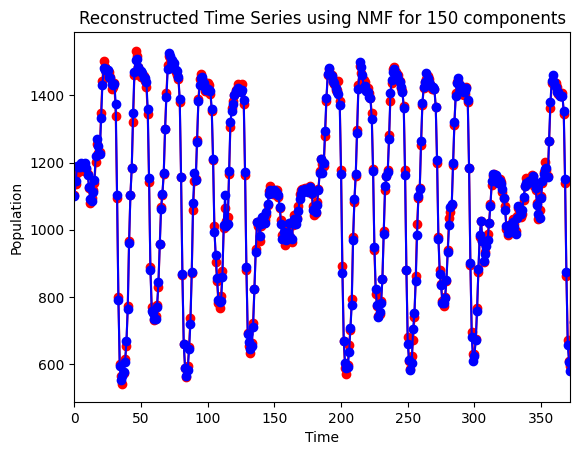

In [41]:

# Perform NMF
model = NMF(n_components=150, init='random', random_state=0)
W_20 = model.fit_transform(X_ssa)
H_20 = model.components_

print("W matrix:\n", W_20)
print("H matrix:\n", H_20)

# Plot the reconstructed time series
reconstructed_time_series_20 = W_20 @ H_20
plt.plot(reconstructed_time_series_20.flatten(), marker='o', linestyle='-', color='red')
plt.plot(time_series, marker='o', linestyle='-', color='Blue')
plt.xlabel("Time")
plt.xlim(0, 372)
plt.ylabel("Population")
plt.title("Reconstructed Time Series using NMF for 150 components")
plt.show()

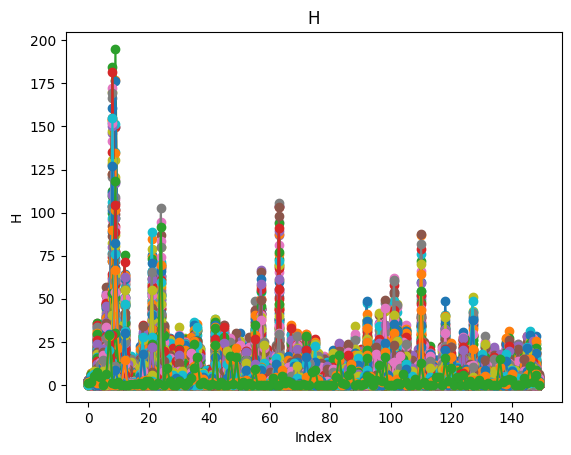

In [42]:
plt.plot(H_20, marker='o', linestyle='-')    
# plt.plot(time_series, marker='o', linestyle='-', color='Blue')
plt.xlabel("Index")
# plt.xlim(0, 372)
plt.ylabel("H")
plt.title("H")
plt.show()


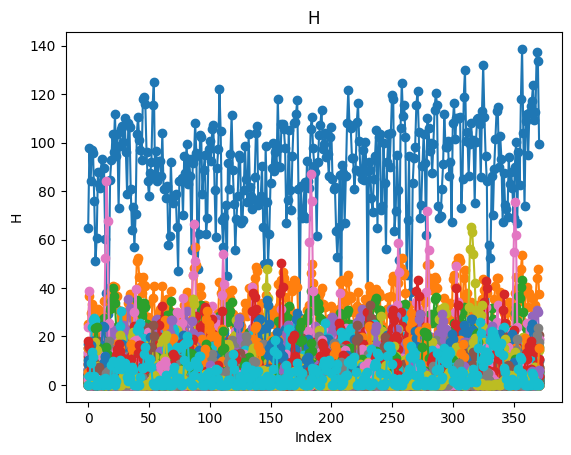

In [43]:
plt.plot(W_20, marker='o', linestyle='-')    
# plt.plot(time_series, marker='o', linestyle='-', color='Blue')
plt.xlabel("Index")
# plt.xlim(0, 372)
plt.ylabel("H")
plt.title("H")
plt.show()


In [44]:
# Calculate the error
mse, mae = calculate_error(X_ssa, reconstructed_time_series_20)

# Print the results
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 137.26716229095598
Mean Absolute Error: 8.990800646602429


W matrix:
 [[3.82408685e+00 9.69465741e+00 1.20855781e+01 ... 9.56321090e-01
  1.35792430e+00 1.52696491e+00]
 [6.85038113e+00 8.99742866e+00 4.32742984e+00 ... 9.66549612e-01
  4.47381464e-01 1.02350224e+00]
 [1.12516168e+01 5.78139830e+00 3.45158820e+00 ... 2.84831181e-01
  9.07690704e-01 1.08047533e-02]
 ...
 [3.55688605e+01 1.13345709e+01 1.91029548e+01 ... 5.70515679e+00
  2.69382785e+00 2.11182158e+00]
 [3.90587110e+01 2.19341955e+01 1.90212750e+01 ... 5.23673202e+00
  2.05694773e+00 4.13369602e+00]
 [3.73984869e+01 3.22180806e+01 2.26504464e+01 ... 5.35016240e+00
  0.00000000e+00 3.93187477e+00]]
H matrix:
 [[ 1.88037361  2.0837332   1.1360881  ...  1.38964693  2.30047841
   2.41074576]
 [ 0.          1.40610506  2.41535488 ...  2.8245906   2.15797209
   1.72236191]
 [ 8.03749052  5.97173453  5.18408279 ...  5.96693339  4.29375197
   3.51573168]
 ...
 [ 0.          0.          1.29278163 ...  1.79075481  2.2776156
   5.31643013]
 [ 6.43195452  4.44410684  2.91607786 ...  0.84889

c:\Users\divya\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_nmf.py:1770: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


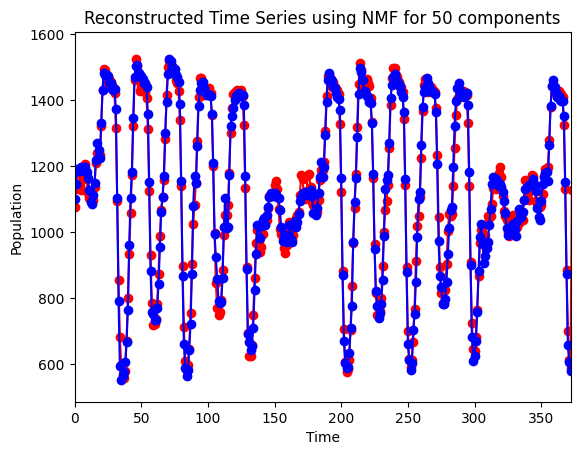

In [45]:

# Perform NMF
model = NMF(n_components=50, init='random', random_state=0)
W_20 = model.fit_transform(X_ssa)
H_20 = model.components_

print("W matrix:\n", W_20)
print("H matrix:\n", H_20)

# Plot the reconstructed time series
reconstructed_time_series_20 = W_20 @ H_20
plt.plot(reconstructed_time_series_20.flatten(), marker='o', linestyle='-', color='red')
plt.plot(time_series, marker='o', linestyle='-', color='Blue')
plt.xlabel("Time")
plt.xlim(0, 372)
plt.ylabel("Population")
plt.title("Reconstructed Time Series using NMF for 50 components")
plt.show()

In [46]:
# Calculate the error
mse, mae = calculate_error(X_ssa, reconstructed_time_series_20)

# Print the results
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 1003.5079650013763
Mean Absolute Error: 24.177883599583076


W matrix:
 [[31.16266022  9.82493225  4.66644222 ...  4.90551537  4.56856247
   4.15266849]
 [32.95275047 10.8405546   2.13798684 ...  3.46049112  5.74494049
   1.64756402]
 [35.96778111  7.68143462  0.         ...  1.46910422  7.63799422
   0.        ]
 ...
 [ 9.87324245  6.48432071  9.24475765 ...  1.36864929  4.25091777
   0.        ]
 [ 7.95960899  5.93937224  6.28939192 ...  1.04754911  5.63113368
   1.63859432]
 [ 8.32204777  4.72357653  3.48466689 ...  0.57367488 10.64631262
   4.35828273]]
H matrix:
 [[ 5.19424322  5.99688153  5.64060973 ...  1.81341168  1.75376434
   0.77462669]
 [ 3.07250753  3.14078888  1.71374035 ...  8.44638097  8.99551685
   9.22813833]
 [14.22164184 15.5788078  15.82424535 ...  8.49140442  6.8350411
   4.79760024]
 ...
 [ 0.52065162  0.40133748  1.03985523 ...  0.          0.
   0.        ]
 [ 2.13859692  3.63109993  3.54890207 ...  1.30585047  0.
   0.47423945]
 [12.18907261 12.54258886 11.32417489 ... 18.60169032 13.99221729
   8.68391121]]


c:\Users\divya\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_nmf.py:1770: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


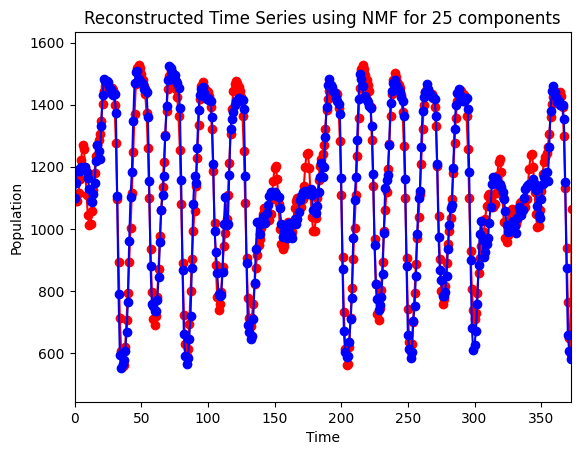

In [47]:

# Perform NMF
model = NMF(n_components=25, init='random', random_state=0)
W_20 = model.fit_transform(X_ssa)
H_20 = model.components_

print("W matrix:\n", W_20)
print("H matrix:\n", H_20)

# Plot the reconstructed time series
reconstructed_time_series_20 = W_20 @ H_20
plt.plot(reconstructed_time_series_20.flatten(), marker='o', linestyle='-', color='red')
plt.plot(time_series, marker='o', linestyle='-', color='Blue')
plt.xlabel("Time")
plt.xlim(0, 372)
plt.ylabel("Population")
plt.title("Reconstructed Time Series using NMF for 25 components")
plt.show()

It looks like you have provided a detailed set of variables and their values, including numpy arrays, pandas DataFrames, and other data types. This data appears to be related to some form of time series analysis, possibly involving Singular Spectrum Analysis (SSA) and Non-negative Matrix Factorization (NMF).

Here is a summary of the key variables and their types:

1. **Vt_ssa**: A numpy array representing some matrix, possibly related to Singular Spectrum Analysis.
2. **W_20**: A numpy array, likely representing a matrix used in NMF with 20 components.
3. **X_ssa**: A numpy array representing the original time series data in matrix form.
4. **data**: A pandas DataFrame containing datetime, count, and hour columns, representing the raw time series data.
5. **hourly_data**: A pandas DataFrame containing hourly aggregated data.
6. **mae**: A numpy float representing the Mean Absolute Error.
7. **min_index**: A numpy int representing the index of the minimum value in the time series.
8. **min_value**: A numpy float representing the minimum value in the time series.
9. **model**: An instance of the NMF model from scikit-learn.
10. **mse**: A numpy float representing the Mean Squared Error.
11. **negative_values_in_H**: A numpy bool indicating if there are negative values in matrix H.
12. **negative_values_in_U**: A numpy bool indicating if there are negative values in matrix U.
13. **negative_values_in_W**: A numpy bool indicating if there are negative values in matrix W.
14. **negative_values_in_vt**: A numpy bool indicating if there are negative values in matrix Vt.
15. **num_components**: An int representing the number of components used in the analysis.
16. **october_data**: A pandas DataFrame containing data for October.
17. **rank_20_approximation**: A numpy array representing the rank-20 approximation of the time series.
18. **rank_5_approximation**: A numpy array representing the rank-5 approximation of the time series.
19. **rank_60_approximation**: A numpy array representing the rank-60 approximation of the time series.
20. **rank_90_approximation**: A numpy array representing the rank-90 approximation of the time series.
21. **reconstructed_time_series**: A numpy array representing the reconstructed time series.
22. **reconstructed_time_series_20**: A numpy array representing the reconstructed time series using 20 components.
23. **reconstructed_time_series_rank_20**: A numpy array representing the reconstructed time series using rank-20 approximation.
24. **reconstructed_time_series_rank_5**: A numpy array representing the reconstructed time series using rank-5 approximation.
25. **reconstructed_time_series_rank_60**: A numpy array representing the reconstructed time series using rank-60 approximation.
26. **reconstructed_time_series_rank_90**: A numpy array representing the reconstructed time series using rank-90 approximation.
27. **svd**: A function from numpy for Singular Value Decomposition.
28. **time_series**: A numpy array representing the original time series data.
29. **time_series_matrix**: A numpy array representing the time series data in matrix form.
30. **window_length**: An int representing the window length used in the analysis.

If you need any specific analysis or operations to be performed on this data, please let me know!

In [48]:
# Calculate the error
mse, mae = calculate_error(X_ssa, reconstructed_time_series_20)

# Print the results
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 2967.3304880123496
Mean Absolute Error: 42.195088260203086


In [49]:
# Check for negative values in H_20 matrix
negative_values_in_H = (H_20 < 0).any()
print("Are there any negative values in H_20 matrix?", negative_values_in_H)

# Check for negative values in W_20 matrix
negative_values_in_W = (W_20 < 0).any()
print("Are there any negative values in W_20 matrix?", negative_values_in_W)

Are there any negative values in H_20 matrix? False
Are there any negative values in W_20 matrix? False
